# ML Training Pipeline - Notebook de Recherche

Ce notebook demontre le workflow complet du pipeline ML :
1. Chargement des donnees OHLCV
2. Visualisation et exploration
3. Feature engineering
4. Entrainement des modeles (dry-run)
5. Evaluation des checkpoints sauvegardes

**Pour un entrainement GPU complet**, utiliser les scripts `train_*.py` en CLI.

In [1]:
import sys
from pathlib import Path

# Robust path setup: find scripts/ dir containing the pipeline modules
# Walk up from CWD looking for scripts/train_classification.py as marker
_candidates = []
_p = Path.cwd()
for _ in range(6):
    _candidates.append(_p / "scripts")
    _p = _p.parent

_scripts_dir = None
for c in _candidates:
    if (c / "train_classification.py").exists():
        _scripts_dir = c
        break

if _scripts_dir is None:
    raise FileNotFoundError("Cannot find scripts/ directory with train_classification.py")
sys.path.insert(0, str(_scripts_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Dependances chargees")
print(f"Scripts dir: {_scripts_dir}")

Dependances chargees
Scripts dir: D:\dev\CoursIA\MyIA.AI.Notebooks\QuantConnect\ML-Training-Pipeline\scripts


## 1. Chargement des Donnees

Utilise les donnees telechargees via `scripts/datasets/` ou des donnees synthetiques pour demo.

In [2]:
from data_utils import generate_synthetic_data, load_data, compute_data_hash
from features import FeatureEngineer

data_dir = Path("datasets/yfinance")
symbol = "SPY"

if data_dir.exists():
    raw = load_data(data_dir, symbol)
    print(f"Donnees reelles : {len(raw)} lignes, {raw.index.min().date()} -> {raw.index.max().date()}")
else:
    raw = generate_synthetic_data(3000)
    print(f"Donnees synthetiques : {len(raw)} lignes")

engineer = FeatureEngineer(lookback=20)

Donnees synthetiques : 3000 lignes


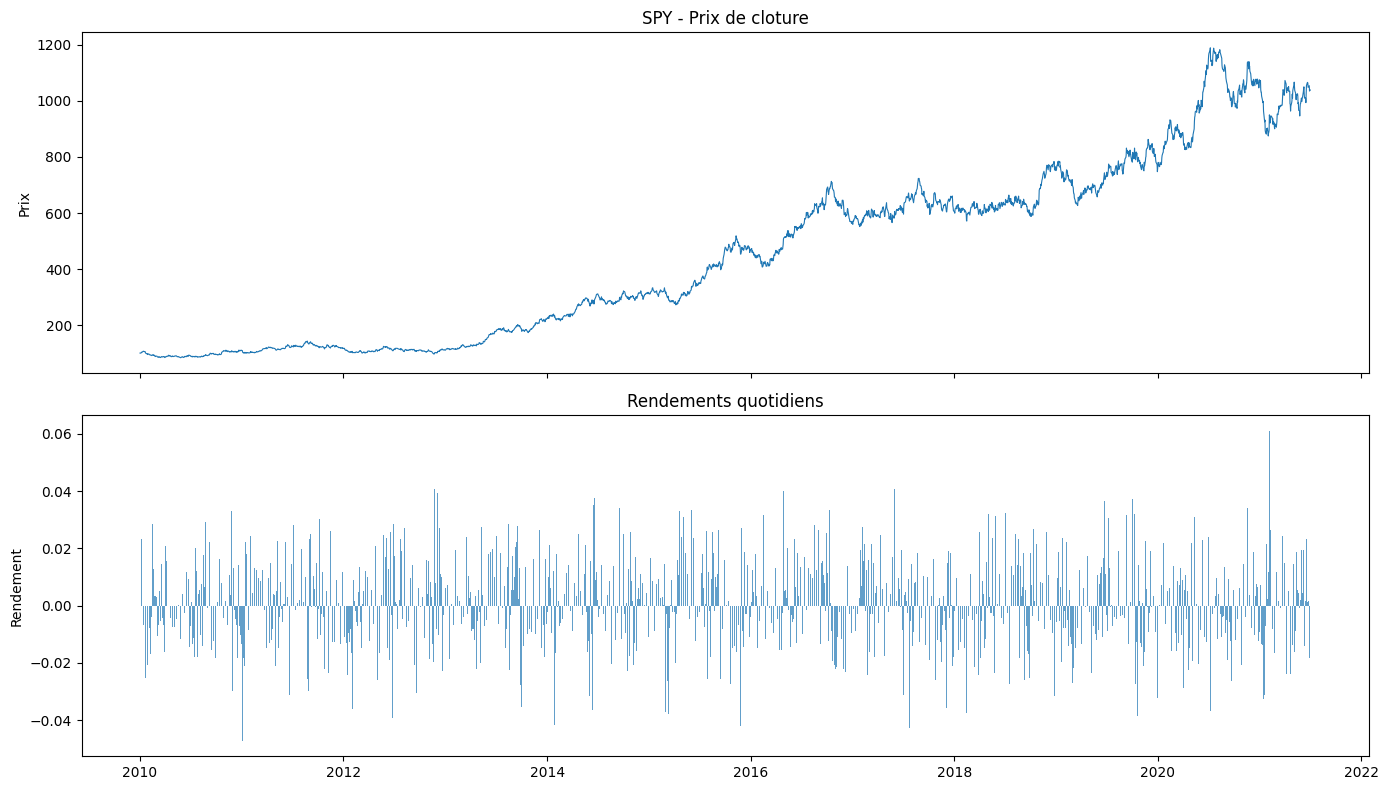

Rendement moyen: 0.00089
Volatilite annualisee: 0.2353


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(raw.index, raw["Close"], linewidth=0.8)
axes[0].set_title(f"{symbol} - Prix de cloture")
axes[0].set_ylabel("Prix")

returns = raw["Close"].pct_change().dropna()
axes[1].bar(returns.index, returns.values, width=1, alpha=0.7)
axes[1].set_title("Rendements quotidiens")
axes[1].set_ylabel("Rendement")

plt.tight_layout()
plt.show()

print(f"Rendement moyen: {returns.mean():.5f}")
print(f"Volatilite annualisee: {returns.std() * np.sqrt(252):.4f}")

## 2. Feature Engineering

Creation des features techniques : rendements multi-horizon, volatilite, RSI, MACD, Bollinger Bands.

In [4]:
features = engineer.transform(raw)
print(f"Features generees : {features.shape}")
print(f"Colonnes : {list(features.columns[:10])}... ({len(features.columns)} total)")

features.describe()

Features generees : (2800, 38)
Colonnes : ['ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'vol_5d', 'vol_20d', 'vol_ratio', 'ma_ratio_5', 'ma_ratio_10', 'ma_ratio_20']... (38 total)


,ret_1d,ret_5d,ret_10d,ret_20d,vol_5d,vol_20d,vol_ratio,ma_ratio_5,ma_ratio_10,ma_ratio_20,...,williams_r_28,skewness,kurtosis,autocorr,downside_vol,upside_vol,acceleration_5,acceleration_10,acceleration_20,target
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,...,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,0.000964,0.004822,0.009666,0.019239,0.013968,0.014674,0.999189,1.001751,1.003979,1.008396,...,-43.826140,0.057989,0.023457,-0.061576,0.007988,0.008892,-0.000007,0.000028,0.000012,0.000969
std,0.014882,0.033078,0.046945,0.067487,0.005227,0.002425,1.126142,0.016195,0.024909,0.036899,...,29.912931,0.487368,1.035191,0.226107,0.002000,0.002180,0.020899,0.020846,0.021146,0.014879
min,-0.047170,-0.101775,-0.132353,-0.184494,0.000746,0.008295,0.018749,0.952037,0.926022,0.885417,...,-99.972674,-2.417940,-1.823116,-0.725784,0.002132,0.002949,-0.065017,-0.079824,-0.070392,-0.047170
25%,-0.009043,-0.017461,-0.022481,-0.027632,0.010187,0.012973,0.322231,0.990976,0.987478,0.983597,...,-69.497681,-0.253425,-0.669865,-0.214090,0.006632,0.007388,-0.014518,-0.013277,-0.013773,-0.009034
50%,0.000686,0.003672,0.007617,0.016559,0.013745,0.014678,0.632618,1.001807,1.003823,1.007208,...,-39.748085,0.072953,-0.197187,-0.063169,0.007904,0.008858,-0.000218,-0.000191,0.000246,0.000686
75%,0.010576,0.026435,0.040525,0.063236,0.017357,0.016275,1.236939,1.012604,1.019879,1.032145,...,-16.550693,0.360116,0.436605,0.098457,0.009236,0.010353,0.014015,0.013580,0.013952,0.010576
max,0.060981,0.126519,0.189904,0.259339,0.034367,0.024008,11.567945,1.057339,1.089759,1.124132,...,-0.051866,1.631855,8.441795,0.563215,0.014185,0.015060,0.079970,0.076515,0.081985,0.060981


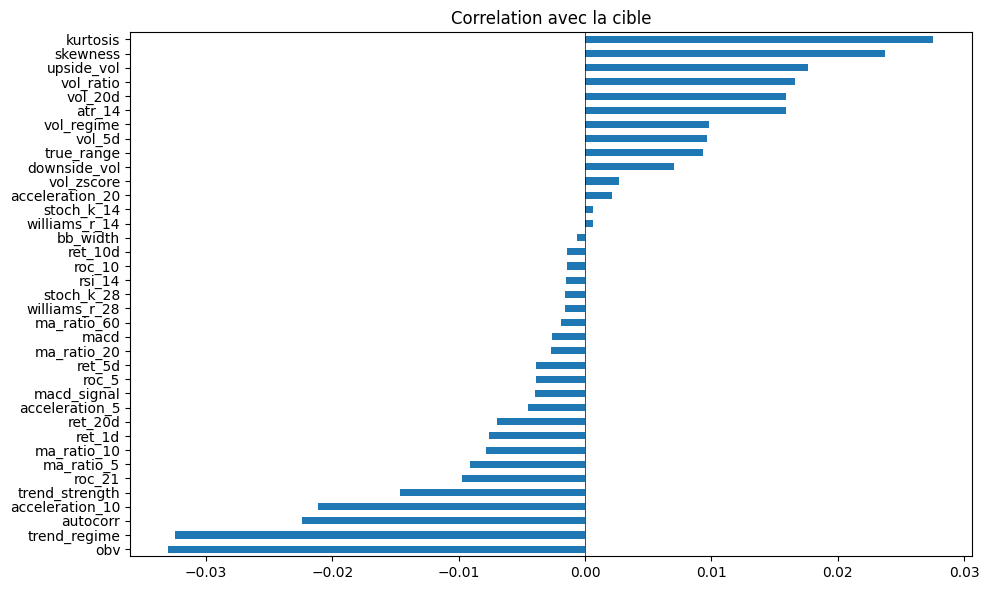

In [5]:
target_col = "target"
if target_col in features.columns:
    corr = features.corr()[target_col].drop(target_col).sort_values()

    fig, ax = plt.subplots(figsize=(10, 6))
    corr.plot(kind="barh", ax=ax)
    ax.set_title("Correlation avec la cible")
    ax.axvline(0, color="black", linewidth=0.5)
    plt.tight_layout()
    plt.show()

## 3. Entrainement - Dry Run

Validation du pipeline avec donnees synthetiques. Pour un entrainement complet sur GPU, utiliser :
```bash
python scripts/train_lstm.py --data-dir ../datasets/yfinance --symbol SPY --hidden-size 512 --epochs 200
```

In [6]:
from train_classification import train_and_evaluate

synth = generate_synthetic_data(500)
synth_features = engineer.transform(synth)
data_hash = compute_data_hash(synth)

# Binarize target: 1 if positive forward return, 0 otherwise
synth_features["target"] = (synth_features["target"] > 0).astype(int)

result_rf = train_and_evaluate(synth_features, model_type="rf", n_estimators=50, max_depth=5)
print(f"RandomForest : Accuracy={result_rf['metrics']['accuracy']}, F1={result_rf['metrics']['f1']}")

RandomForest : Accuracy=0.3333, F1=0.2234


In [7]:
from sequence_utils import build_sequences, normalize_sequences
from train_lstm import train_and_evaluate as train_lstm_model

lstm_features = engineer.transform(synth)
X, y, feat_cols = build_sequences(lstm_features, seq_len=20)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
X_train, X_test, _, _ = normalize_sequences(X_train, X_test)

lstm_result = train_lstm_model(X_train, y_train, X_test, y_test,
    hidden_size=64, num_layers=1, epochs=2, batch_size=32, device="cpu")
print(f"LSTM : MSE={lstm_result['metrics']['mse']:.6f}, DirAcc={lstm_result['metrics']['direction_accuracy']}")

  Epoch 1/2  train=0.002215  val=0.000934  GPU=63C


  Epoch 2/2  train=0.001707  val=0.000878  GPU=63C
LSTM : MSE=0.001175, DirAcc=0.6071


## 4. Evaluation d'un Checkpoint

Chargement et evaluation d'un modele sauvegarde. Requiert un checkpoint existant.

In [8]:
import json

ckpt_base = Path("../checkpoints")
all_ckpts = []

if ckpt_base.exists():
    for model_dir in ckpt_base.iterdir():
        if model_dir.is_dir():
            for ts_dir in model_dir.iterdir():
                if ts_dir.is_dir() and (ts_dir / "metadata.json").exists():
                    meta = json.loads((ts_dir / "metadata.json").read_text())
                    all_ckpts.append({"path": str(ts_dir), **meta})

if all_ckpts:
    latest = sorted(all_ckpts, key=lambda x: x["timestamp"])[-1]
    print(f"Checkpoint le plus recent : {latest['path']}")
    print(f"Modele : {latest['model_type']}")
    print(f"Metriques : {latest['metrics']}")
    print(f"Data hash : {latest['data_hash']}")
else:
    print("Aucun checkpoint trouve. Lancez un entrainement d'abord.")

Aucun checkpoint trouve. Lancez un entrainement d'abord.


## 5. Resume

| Etape | Status |
|-------|--------|
| Chargement donnees | OK |
| Feature engineering | OK |
| Dry-run classification | OK |
| Dry-run LSTM | OK |
| Checkpoint evaluation | A verifier apres entrainement |

Prochaines etapes : lancer les entrainements GPU complets via les scripts CLI.